In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import make_moons
data = make_moons(n_samples=1000,noise=0.1)
df = pd.DataFrame({'X':data[0][:,0],'Y':data[0][:,1],'class':data[1]})
df.head()

,X,Y,class
0,0.148291,0.069129,1
1,-0.799904,0.394536,0
2,1.911246,0.158968,1
3,-0.104761,0.331628,1
4,1.710854,-0.301070,1


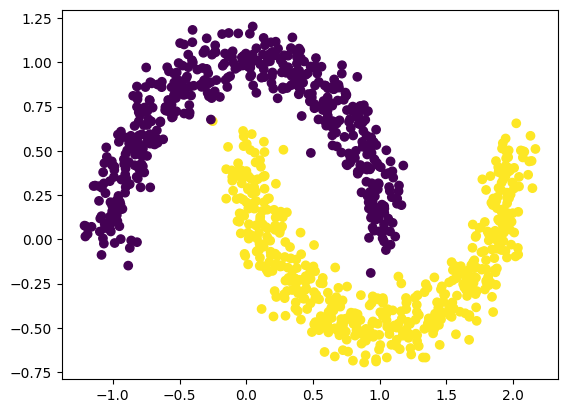

In [3]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [74]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [75]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [76]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(1,activation='linear'))

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [77]:
# Set parameters to 0
model.get_weights()

[array([[-0.70459026, -0.5996999 ,  0.48638588,  0.46279377,  0.5463951 ,
         -0.20032346, -0.69575596,  0.08725053, -0.49391907, -0.24629825],
        [-0.3995066 , -0.6034122 , -0.13501543,  0.48904556, -0.26749492,
         -0.05708688,  0.24697226, -0.1560598 ,  0.24784487, -0.31500185]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.19785953],
        [ 0.38550776],
        [ 0.5489058 ],
        [ 0.60664004],
        [ 0.14507282],
        [-0.4560653 ],
        [ 0.4825967 ],
        [ 0.17533684],
        [-0.27610412],
        [-0.15652174]], dtype=float32),
 array([0.], dtype=float32)]

In [78]:
initial_weights = model.get_weights()

In [82]:
initial_weights[1] = np.ones(model.get_weights()[1].shape)*0.5
initial_weights[2] = np.ones(model.get_weights()[2].shape)*0.5
initial_weights[3] = np.ones(model.get_weights()[3].shape)*0.5

In [83]:
model.set_weights(initial_weights)

In [84]:
model.get_weights()

[array([[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]], dtype=float32),
 array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], dtype=float32),
 array([[0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5]], dtype=float32),
 array([0.5], dtype=float32)]

In [85]:
model.compile(loss='mse',optimizer='adam',metrics=['accuracy'])

In [86]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5321 - loss: 21.8648 - val_accuracy: 0.4950 - val_loss: 17.9536
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5311 - loss: 17.7629 - val_accuracy: 0.4950 - val_loss: 14.5740
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5307 - loss: 14.8197 - val_accuracy: 0.5000 - val_loss: 11.9213
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5198 - loss: 12.2192 - val_accuracy: 0.5000 - val_loss: 9.7931
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5143 - loss: 9.8592 - val_accuracy: 0.5000 - val_loss: 8.0801
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5005 - loss: 8.0777 - val_accuracy: 0.5000 - val_loss: 6.7393
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5244 - loss: 6.9084 - val_accuracy: 0.5050 - val_loss: 5.6313
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5615 - loss: 5.4941 - val_accuracy: 0.

In [87]:
model.get_weights()

[array([[ 0.19205879,  0.19205879,  0.19205879,  0.19205879,  0.19205879,
          0.19205879,  0.19205879,  0.19205879,  0.19205879,  0.19205879],
        [-0.13720573, -0.13720573, -0.13720573, -0.13720573, -0.13720573,
         -0.13720573, -0.13720573, -0.13720573, -0.13720573, -0.13720573]],
       dtype=float32),
 array([0.18257192, 0.18257192, 0.18257192, 0.18257192, 0.18257192,
        0.18257192, 0.18257192, 0.18257192, 0.18257192, 0.18257192],
       dtype=float32),
 array([[0.17311855],
        [0.17311855],
        [0.17311855],
        [0.17311855],
        [0.17311855],
        [0.17311855],
        [0.17311855],
        [0.17311855],
        [0.17311855],
        [0.17311855]], dtype=float32),
 array([0.05618418], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


<Axes: >

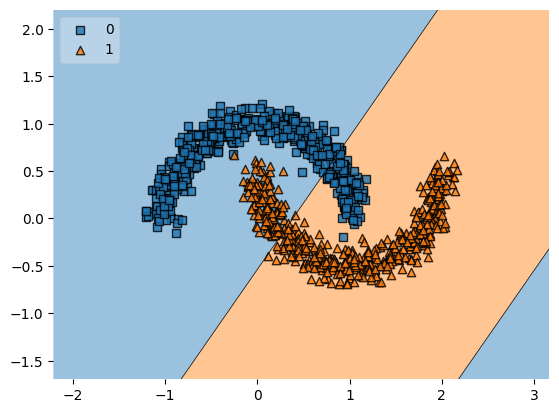

In [88]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)